In [1]:
import torch
import torch.nn as nn
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
from torch.utils.data.sampler import SubsetRandomSampler
import torchvision.transforms as transforms
import torch.nn.functional as F
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.tensorboard import SummaryWriter
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm 
from datetime import datetime
from torchsummary import summary

In [2]:
torch.__version__

'2.2.1'

In [3]:
class MLPNet(nn.Module):
    def __init__(self) -> None:
        super(MLPNet, self).__init__()
        self.fc1 = nn.Linear(28*28, 500)
        self.fc2 = nn.Linear(500, 256)
        self.fc3 = nn.Linear(256, 10)
        
    def forward(self, x):
        x = x.view(-1, 28*28)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x
    
    def name(self):
        return "MLP"

In [4]:
def train_model(dataloader, model, device, optimizer, criterion):
    model.train()
    net_loss = 0
    for inputs, targets in dataloader:
        inputs = inputs.to(device)
        targets = targets.to(device)
        optimizer.zero_grad()
        pred = model(inputs)
        loss = criterion(pred, targets)
        loss.backward()
        optimizer.step()
        net_loss += loss.item()
    return net_loss/len(dataloader)

In [5]:
def validate_model(dataloader, model, device, criterion):
    net_loss = 0
    model.eval()
    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs = inputs.to(device)
            targets = targets.to(device)
            pred = model(inputs)
            loss = criterion(pred, targets)
            net_loss += loss.item()
    return net_loss/len(dataloader)

In [6]:
def test_model(dataloader, model, device, optimizer, criterion):
    net_loss = 0
    model.eval()
    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs = inputs.to(device)
            targets = targets.to(device)
            pred = model(inputs)
            loss = criterion(pred, targets)
            net_loss += loss.item()
    return net_loss/len(dataloader)

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [8]:
model = MLPNet()
model = model.to(device)

In [9]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Number of parameters: {total_params}")

Number of parameters: 523326


In [10]:
criterion = nn.CrossEntropyLoss()
# optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
scheduler = ReduceLROnPlateau(optimizer, 'min', patience=10)

In [11]:
# number of subprocesses to use for data loading
num_workers = 0
# how many samples per batch to load
batch_size = 100
# percentage of training set to use as validation
valid_size = 0.2

# convert data to torch.FloatTensor
transform = transforms.ToTensor()

# choose the training and test datasets
train_data = datasets.MNIST(root='data', train=True, download=True, transform=transform)
test_data = datasets.MNIST(root='data', train=False, download=True, transform=transform)

# obtain training indices that will be used for validation
num_train = len(train_data)
indices = list(range(num_train))
np.random.shuffle(indices)
split = int(np.floor(valid_size * num_train))
train_idx, valid_idx = indices[split:], indices[:split]

# define samplers for obtaining training and validation batches
train_sampler = SubsetRandomSampler(train_idx)
valid_sampler = SubsetRandomSampler(valid_idx)

In [12]:
# prepare data loaders
train_dataloader = DataLoader(train_data, batch_size=batch_size, sampler=train_sampler, num_workers=num_workers)
validate_dataloader = DataLoader(train_data, batch_size=batch_size, sampler=valid_sampler, num_workers=num_workers)
test_dataloader = DataLoader(test_data, batch_size=batch_size, num_workers=num_workers)

In [13]:
summary(model, input_size=(1, 28, 28), batch_size=batch_size)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                 [100, 500]         392,500
            Linear-2                 [100, 256]         128,256
            Linear-3                  [100, 10]           2,570
Total params: 523,326
Trainable params: 523,326
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.30
Forward/backward pass size (MB): 0.58
Params size (MB): 2.00
Estimated Total Size (MB): 2.88
----------------------------------------------------------------


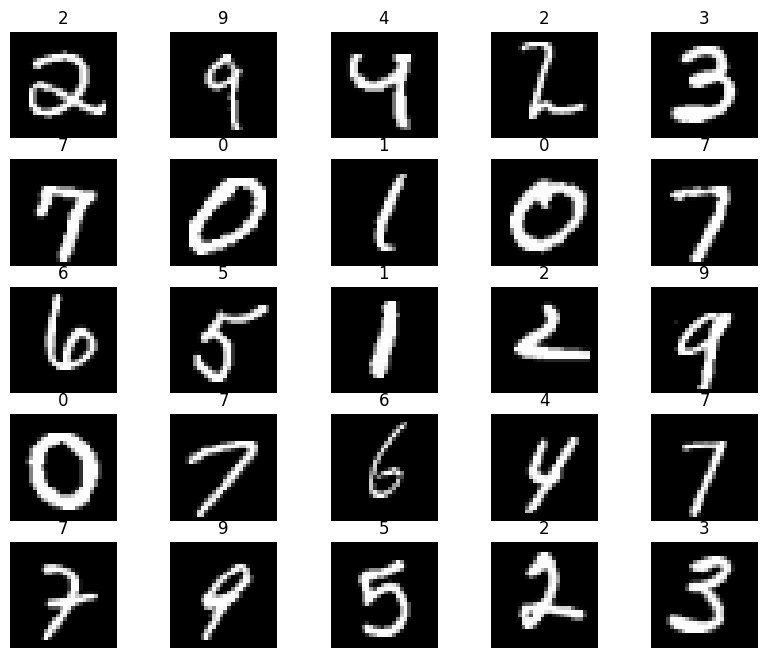

In [14]:
figure = plt.figure(figsize=(10, 8))
cols, rows = 5, 5
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(train_data), size=(1,)).item()
    img, label = train_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(label)
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

In [15]:
writer = SummaryWriter("MLPNet")

In [16]:
best_validation_loss = float('inf')

In [17]:
model_weights_path = r"/workspaces/ai/lec05/weights/mlp_weights.pth"
num_iters = 50

In [18]:
start_time = datetime.now()
for epoch in range(num_iters):
    training_loss = train_model(train_dataloader, model, device, optimizer, criterion)
    writer.add_scalar("Training Loss", training_loss, epoch)
    validation_loss = validate_model(validate_dataloader, model, device, criterion)
    if validation_loss < best_validation_loss:
        best_validation_loss = validation_loss
        torch.save(model.state_dict(), model_weights_path)
    writer.add_scalar("Validation Loss", validation_loss, epoch)
    print("epoch: ", epoch, " training loss: ", training_loss, " validation loss: ", validation_loss, " lr: ", optimizer.param_groups[0]['lr'])
    scheduler.step(validation_loss)
writer.close()
end_time = datetime.now()
print("Training time: ", end_time-start_time)

epoch:  0  training loss:  2.116561311731736  validation loss:  1.7238690912723542  lr:  0.01
epoch:  1  training loss:  1.1052387040108442  validation loss:  0.7205062627792358  lr:  0.01
epoch:  2  training loss:  0.5806740945205092  validation loss:  0.49968159447113675  lr:  0.01
epoch:  3  training loss:  0.4492258172482252  validation loss:  0.4178011907885472  lr:  0.01
epoch:  4  training loss:  0.39206874994561075  validation loss:  0.3796300002684196  lr:  0.01
epoch:  5  training loss:  0.3589624696411192  validation loss:  0.350713500007987  lr:  0.01
epoch:  6  training loss:  0.33631257169569534  validation loss:  0.3293020570029815  lr:  0.01
epoch:  7  training loss:  0.3188481645969053  validation loss:  0.3139515706648429  lr:  0.01
epoch:  8  training loss:  0.3044341267707447  validation loss:  0.30137448323269683  lr:  0.01
epoch:  9  training loss:  0.2919381620362401  validation loss:  0.28809636905789376  lr:  0.01
epoch:  10  training loss:  0.28040499372097355

In [19]:
model.load_state_dict(torch.load(model_weights_path))

<All keys matched successfully>

In [20]:
# initialize lists to monitor test loss and accuracy
test_loss = 0.0
class_correct = list(0. for i in range(10))
class_total = list(0. for i in range(10))

model.eval() # prep model for evaluation

for data, target in test_dataloader:
    # forward pass: compute predicted outputs by passing inputs to the model
    output = model(data)
    # calculate the loss
    loss = criterion(output, target)
    # update test loss 
    test_loss += loss.item()*data.size(0)
    # convert output probabilities to predicted class
    _, pred = torch.max(output, 1)
    # compare predictions to true label
    correct = np.squeeze(pred.eq(target.data.view_as(pred)))
    # calculate test accuracy for each object class
    for i in range(batch_size):
        label = target.data[i]
        class_correct[label] += correct[i].item()
        class_total[label] += 1

# calculate and print avg test loss
test_loss = test_loss/len(test_dataloader.dataset)
print('Test Loss: {:.6f}\n'.format(test_loss))

for i in range(10):
    if class_total[i] > 0:
        print('Test Accuracy of %5s: %2d%% (%2d/%2d)' % (
            str(i), 100 * class_correct[i] / class_total[i],
            np.sum(class_correct[i]), np.sum(class_total[i])))
    else:
        print('Test Accuracy of %5s: N/A (no training examples)' % (classes[i]))

print('\nTest Accuracy (Overall): %2d%% (%2d/%2d)' % (
    100. * np.sum(class_correct) / np.sum(class_total),
    np.sum(class_correct), np.sum(class_total)))

Test Loss: 0.111416

Test Accuracy of     0: 98% (963/980)
Test Accuracy of     1: 98% (1115/1135)
Test Accuracy of     2: 96% (997/1032)
Test Accuracy of     3: 97% (983/1010)
Test Accuracy of     4: 96% (947/982)
Test Accuracy of     5: 94% (847/892)
Test Accuracy of     6: 96% (924/958)
Test Accuracy of     7: 96% (988/1028)
Test Accuracy of     8: 95% (928/974)
Test Accuracy of     9: 95% (961/1009)

Test Accuracy (Overall): 96% (9653/10000)
